# Importing Library

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from magic import MagicTouch as mt
from category_encoders import OneHotEncoder
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.feature_selection import f_classif
from sentence_transformers import SentenceTransformer
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GridSearchCV,  StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import f1_score
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier

## loding data set

In [28]:
df = pd.read_csv("./dataset/train.csv")
df_test = pd.read_csv("./dataset/test.csv")

# Exploring DataSet

In [29]:
df.shape

(6979, 69)

- data is a bit small (rows) best model to fit is a nueral network

- so much features data is complex

In [30]:
df.columns

Index(['id', 'listing_url', 'name', 'summary', 'space', 'description',
       'neighborhood_overview', 'notes', 'transit', 'access', 'interaction',
       'house_rules', 'thumbnail_url', 'host_id', 'host_url', 'host_name',
       'host_since', 'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'street', 'neighbourhood',
       'neighbourhood_cleansed', 'city', 'state', 'zipcode', 'market',
       'smart_location', 'country_code', 'country', 'latitude', 'longitude',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet',
       'nightly_price', 'price_per_stay', 'security_deposit', 'cleaning_fee',
       'guests_included', 'extra_people', 'minimum_nights', 'maximum_nights',

- there are so many useless columns that can be removed 

- url columns might be used for extrating a feature

- any name or id  column will be dropped (if we cant use it in feature engineering)

- target column `guest_satisfaction`

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6979 entries, 0 to 6978
Data columns (total 69 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                6979 non-null   int64  
 1   listing_url                       6979 non-null   str    
 2   name                              6979 non-null   str    
 3   summary                           6808 non-null   str    
 4   space                             5666 non-null   str    
 5   description                       6906 non-null   str    
 6   neighborhood_overview             5160 non-null   str    
 7   notes                             4146 non-null   str    
 8   transit                           4738 non-null   str    
 9   access                            4789 non-null   str    
 10  interaction                       4916 non-null   str    
 11  house_rules                       5414 non-null   str    
 12  thumbnail_url    

- `square feet`, `thumbnail_url` and `host_acceptance_rate` columns will be dropped due to a very large amount of nulls

- also columns with a description like values might be used to make new features

- data is mostly strings (need alot of encoding)

In [32]:
totNulls = sum([df[col].isnull().sum() for col in df.columns])

# calculating null percentage of the data cells

rows, cols = df.shape

cell_number = rows * cols

print(f"null cells = {round((totNulls/ cell_number)* 100, 2)} %")

null cells = 8.68 %


- data cells has only 8% nulls which is pretty good

- note: after dropping the columns with so much nulls from the last cell it will be much much smaller

In [33]:
pd.set_option('display.max_rows', None)
mt.data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,id,int64,"[5083, 2869, 875, 3265, 2248, 3485, 4612, 4713...",6979,0,0.000000,0
1,listing_url,str,"[https://www.airbnb.com/rooms/269843, https://...",6979,0,0.000000,0
2,name,str,"[Smart Home in Downtown of San Diego, Home awa...",6943,0,0.000000,0
3,summary,str,"[Featured in The New York Times, The Wall Stre...",6399,171,2.450208,0
4,space,str,[- Private balcony - In-suite laundry - Fully-...,5369,1313,18.813584,0
5,description,str,"[Featured in The New York Times, The Wall Stre...",6664,73,1.045995,0
6,neighborhood_overview,str,"[South Mission, North Mission, Activities Amus...",4328,1819,26.063906,0
7,notes,str,[We offer rewards and complimentary upgrades t...,3573,2833,40.593208,0
8,transit,str,"[We recommend a car for navigating San Diego, ...",4108,2241,32.110618,0
9,access,str,"[#NAME?, Everything! Guests have access to the...",4241,2190,31.379854,0


In [34]:
id = df_test["id"]

## 📊 Data Insight Summary

Based on the initial exploration of the dataset, the following observations and preprocessing strategies were identified.

---

## 🧹 Preprocessing Status

### Columns to Drop

| Column(s) | Reason |
|-----------|--------|
| `square_feet`, `thumbnail_url`, `host_acceptance_rate` | Contain a very high percentage of missing values, making them unreliable for modeling. |
| `requires_license`, `is_business_travel_ready` | Contain only one unique value, providing no useful information for the model. |
| URL-related columns | Will be removed if no meaningful features can be extracted from them. |

---

### Additional Observations

- The dataset contains a large number of **string/categorical features** that cannot be removed immediately because they may contain valuable information.
- Further analysis will be required to determine which categorical features contribute to the model.

---

## 🔠 Encoding Status

- The dataset requires extensive encoding due to the large number of categorical/string columns.
- Possible encoding techniques:
    - **Label Encoding** for ordinal or binary features.
    - **One-Hot Encoding** for nominal categorical features.
    - Additional encoding strategies may be considered depending on feature cardinality.

---

## ⚙️ Feature Engineering Status

Potential feature engineering opportunities:

### 🌐 URL Features

- URL columns may contain useful information that can be extracted, such as:
    - Number of images.
    - Presence of specific keywords.
    - URL structure features.

### 📍 Location Features

- Coordinate-based features (`latitude`, `longitude`) can be used to create:
    - Distance-based features.
    - Location clusters.
    - Region-based features.

### 🔗 Feature Relationships

- Due to the large number of features, the dataset has a high possibility of containing highly correlated variables.
- Correlation analysis will be performed to identify redundant features.

---

## 🤖 Model Status

Due to:

- The complexity of the dataset.
- The high number of categorical features.
- The relatively limited number of samples.

The following models are considered good candidates:

- 🌲 **Random Forest**
    - Handles complex relationships.
    - Works well with mixed feature types after encoding.

- 🧠 **Neural Networks**
    - Can capture complex nonlinear patterns.
    - May benefit from feature scaling and proper encoding.

Further model evaluation and comparison will determine the best approach.

# Visualization

## Dividing Columns

In [35]:
mt.data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,id,int64,"[5083, 2869, 875, 3265, 2248, 3485, 4612, 4713...",6979,0,0.000000,0
1,listing_url,str,"[https://www.airbnb.com/rooms/269843, https://...",6979,0,0.000000,0
2,name,str,"[Smart Home in Downtown of San Diego, Home awa...",6943,0,0.000000,0
3,summary,str,"[Featured in The New York Times, The Wall Stre...",6399,171,2.450208,0
4,space,str,[- Private balcony - In-suite laundry - Fully-...,5369,1313,18.813584,0
5,description,str,"[Featured in The New York Times, The Wall Stre...",6664,73,1.045995,0
6,neighborhood_overview,str,"[South Mission, North Mission, Activities Amus...",4328,1819,26.063906,0
7,notes,str,[We offer rewards and complimentary upgrades t...,3573,2833,40.593208,0
8,transit,str,"[We recommend a car for navigating San Diego, ...",4108,2241,32.110618,0
9,access,str,"[#NAME?, Everything! Guests have access to the...",4241,2190,31.379854,0


In [36]:
bin_cols = ["instant_bookable", "require_guest_profile_picture",
            "require_guest_phone_verification", "is_location_exact",
            "host_identity_verified", "host_has_profile_pic",
            "host_is_superhost"]

second_vis_cols = ["host_response_rate", "host_listings_count", "nightly_price", "price_per_stay",
                   "security_deposit", "cleaning_fee", "guests_included", "minimum_nights", "maximum_nights",
                   "number_of_reviews", "number_of_stays"]

# ?

## Visualizing

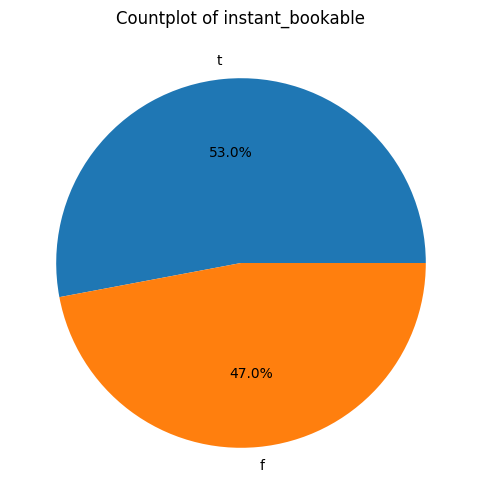

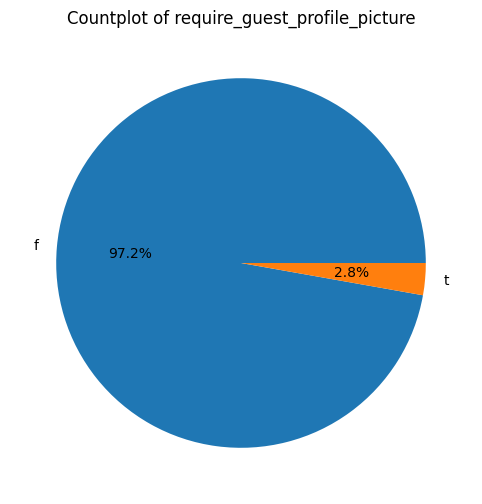

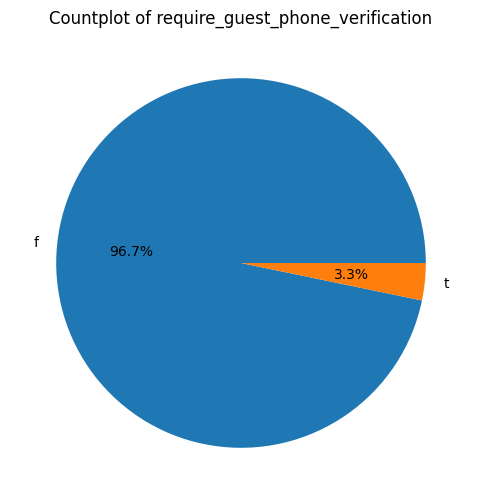

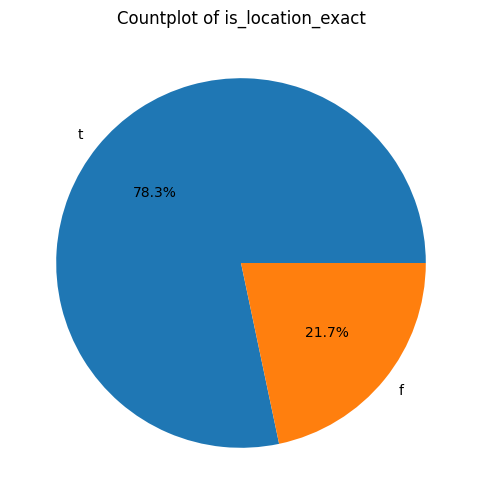

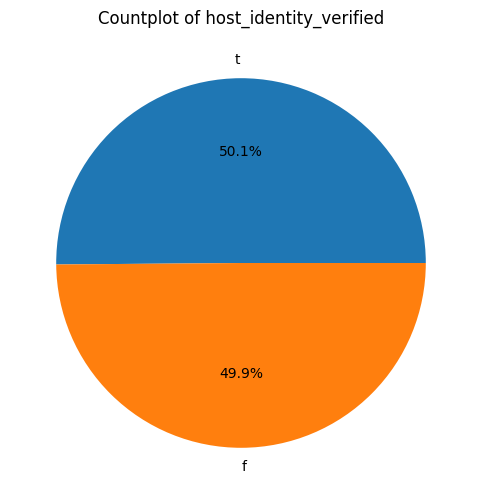

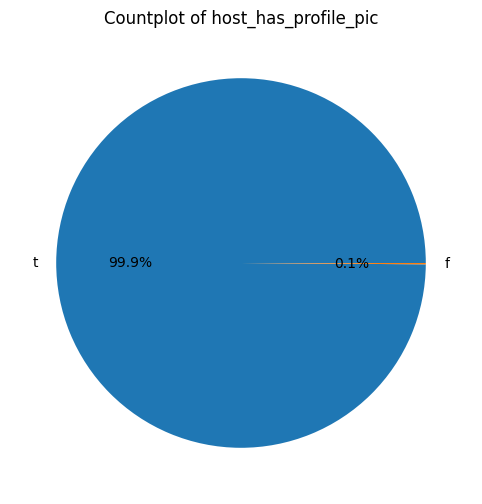

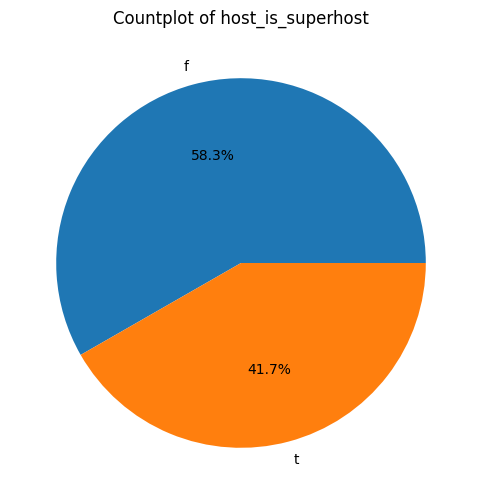

In [37]:
for col in bin_cols:
    plt.figure(figsize=(8, 6))
    plt.pie(df[col].value_counts(), labels=df[col].value_counts().index, autopct='%1.1f%%')
    plt.title(f"Countplot of {col}")
    plt.show()

- columns like `require_guest_profile_picture` will be dropped due to the data being almost one value

In [38]:
to_drop = ["id", "listing_url", "name", "thumbnail_url", "host_url", "name","summary",
            "description", "neighborhood_overview", "notes", "access", "interaction","transit",
            "house_rules", "square_feet", "requires_license", "host_acceptance_rate", "zipcode"]

# adding droped columns we got from visualization

to_drop +=["require_guest_profile_picture", "host_has_profile_pic", "host_has_profile_pic",
            "host_id", "host_name", "host_about"]

# ading columns that might have somthing to do with feature engineering

to_drop += [ "host_location", "neighbourhood", "neighbourhood_cleansed",
             "city", "smart_location", "property_type", "first_review",
             "last_review", "is_business_travel_ready", "host_neighbourhood", "host_total_listings_count", "street"]

In [39]:
mt.data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,id,int64,"[5083, 2869, 875, 3265, 2248, 3485, 4612, 4713...",6979,0,0.000000,0
1,listing_url,str,"[https://www.airbnb.com/rooms/269843, https://...",6979,0,0.000000,0
2,name,str,"[Smart Home in Downtown of San Diego, Home awa...",6943,0,0.000000,0
3,summary,str,"[Featured in The New York Times, The Wall Stre...",6399,171,2.450208,0
4,space,str,[- Private balcony - In-suite laundry - Fully-...,5369,1313,18.813584,0
5,description,str,"[Featured in The New York Times, The Wall Stre...",6664,73,1.045995,0
6,neighborhood_overview,str,"[South Mission, North Mission, Activities Amus...",4328,1819,26.063906,0
7,notes,str,[We offer rewards and complimentary upgrades t...,3573,2833,40.593208,0
8,transit,str,"[We recommend a car for navigating San Diego, ...",4108,2241,32.110618,0
9,access,str,"[#NAME?, Everything! Guests have access to the...",4241,2190,31.379854,0


In [40]:
# adjusting the bin_cols split

bin_cols = [col for col in bin_cols if col not in to_drop]

In [41]:
print(bin_cols)

['instant_bookable', 'require_guest_phone_verification', 'is_location_exact', 'host_identity_verified', 'host_is_superhost']


/tmp/ipykernel_22792/305354882.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["guest_satisfaction"], palette = "magma")


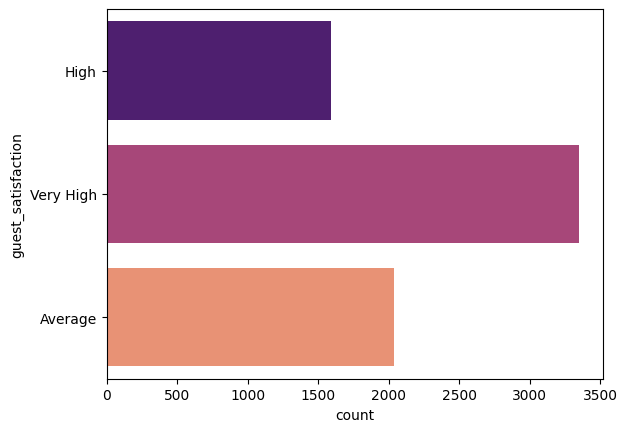

In [42]:
sns.countplot(df["guest_satisfaction"], palette = "magma")
plt.show()

- data is mostly balanced with the majorty being `very high` class

# Preprossecing

In [43]:
# frist dropping the columns

df = df.drop(to_drop, axis = 1)
df_test = df_test.drop(to_drop, axis = 1)

## handling nulls 

In [44]:
mt.data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,space,str,[- Private balcony - In-suite laundry - Fully-...,5369,1313,18.813584,0
1,host_since,str,"[3/22/2017, 8/5/2016, 2/14/2014, 7/16/2015, 8/...",2165,1,0.014329,0
2,host_response_time,str,"[within an hour, within a few hours, within a ...",4,856,12.265368,0
3,host_response_rate,str,"[100%, 99%, 90%, 95%, 97%, 96%, 98%, 91%, 80%,...",47,856,12.265368,0
4,host_is_superhost,str,"[f, t]",2,1,0.014329,0
5,host_listings_count,float64,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 12.0, 8.0,...",86,1,0.014329,0
6,host_identity_verified,str,"[t, f]",2,1,0.014329,0
7,state,str,"[CA, Ca, California, Baja California, B.C., WA]",6,1,0.014329,0
8,market,str,"[San Diego, Carlsbad, Tijuana, Other (Domestic...",6,9,0.128958,0
9,country_code,str,"[US, MX, GB]",3,0,0.000000,0


#### dividing columns by replacment value

In [45]:
# mode replaced columns

mode_replaced_cols = [ "host_is_superhost",
                      "host_listings_count", "host_identity_verified", "state", "market",
                      "bedrooms", "beds"]

# columns that will be worked on or transformed before filling nulls

median_replaced_modified_cols = ["bathrooms", "security_deposit", "cleaning_fee"]

#### modifing all columns to replace them 

In [46]:
# columns to be modified

to_be_modified = []
to_be_modified =  median_replaced_modified_cols + ["price_per_stay", "nightly_price", "extra_people", "host_response_rate"]

for column in to_be_modified:
    df[column] = pd.to_numeric(df[column].replace(r'[$,%]', '', regex=True),errors="coerce")   # added , to temove so the numbers dont turn into nan with to numeric
    df_test[column] = pd.to_numeric(df_test[column].replace(r'[$,%]', '', regex=True),errors="coerce")  




In [47]:
df["host_response_rate"] = df["host_response_rate"].fillna(0)
df_test["host_response_rate"] = df_test["host_response_rate"].fillna(0)

In [48]:
df["bathrooms"] = df["bathrooms"].round()
df_test["bathrooms"] = df_test["bathrooms"].round()

#### filling nulls

In [49]:
# with mode

for col in mode_replaced_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df_test[col] = df_test[col].fillna(df_test[col].mode()[0])

In [50]:
# with median

for col in median_replaced_modified_cols:
    df[col] = df[col].fillna(df[col].median())
    df_test[col] = df_test[col].fillna(df_test[col].median())

In [51]:
mt.data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,space,str,[- Private balcony - In-suite laundry - Fully-...,5369,1313,18.813584,0
1,host_since,str,"[3/22/2017, 8/5/2016, 2/14/2014, 7/16/2015, 8/...",2165,1,0.014329,0
2,host_response_time,str,"[within an hour, within a few hours, within a ...",4,856,12.265368,0
3,host_response_rate,float64,"[100.0, 0.0, 99.0, 90.0, 95.0, 97.0, 96.0, 98....",47,0,0.000000,0
4,host_is_superhost,str,"[f, t]",2,0,0.000000,0
5,host_listings_count,float64,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 12.0, 8.0,...",86,0,0.000000,0
6,host_identity_verified,str,"[t, f]",2,0,0.000000,0
7,state,str,"[CA, Ca, California, Baja California, B.C., WA]",6,0,0.000000,0
8,market,str,"[San Diego, Carlsbad, Tijuana, Other (Domestic...",6,0,0.000000,0
9,country_code,str,"[US, MX, GB]",3,0,0.000000,0


In [52]:
df["space"] = df["space"].fillna("NO SPACE")
df_test["space"] = df_test["space"].fillna("NO SPACE")

In [53]:
# word embedding

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df["space"].tolist(),
    show_progress_bar=True
)


#encoding it

embeddings_train = model.encode(
    df["space"].tolist(),
    show_progress_bar=True
)

embeddings_test = model.encode(
    df_test["space"].tolist(),
    show_progress_bar=True
)

Batches: 100%|██████████| 55/55 [00:23<00:00,  2.36it/s]


In [54]:
# converting them into df and concating them to the main df

embedding_df_train = pd.DataFrame(
    embeddings_train,
    columns=[f"space_emb_{i}" for i in range(embeddings_train.shape[1])]
)

embedding_df_test = pd.DataFrame(
    embeddings_test,
    columns=[f"space_emb_{i}" for i in range(embeddings_test.shape[1])]
)


# now adding them to the main df

df= pd.concat([df.reset_index(drop=True),
                embedding_df_train.reset_index(drop=True)],
               axis=1)


df_test = pd.concat([df_test.reset_index(drop=True),
                embedding_df_test.reset_index(drop=True)],
               axis=1)


# droping the summry column


df = df.drop("space", axis = 1)
df_test = df_test.drop("space", axis = 1)

In [55]:
mt.data_info(df_test)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,host_since,str,"[3/22/2017, 8/5/2016, 8/23/2013, 2/14/2014, 1/...",1067,0,0.000000,0
1,host_response_time,str,"[within an hour, within a few hours, within a ...",4,201,11.518625,0
2,host_response_rate,float64,"[100.0, 0.0, 99.0, 90.0, 95.0, 98.0, 96.0, 97....",34,0,0.000000,0
3,host_is_superhost,str,"[f, t]",2,0,0.000000,0
4,host_listings_count,float64,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 403.0...",76,0,0.000000,0
5,host_identity_verified,str,"[t, f]",2,0,0.000000,0
6,state,str,[CA],1,0,0.000000,0
7,market,str,"[San Diego, Carlsbad, Other (Domestic)]",3,0,0.000000,0
8,country_code,str,[US],1,0,0.000000,0
9,country,str,[United States],1,0,0.000000,0


# 2nd Visualization

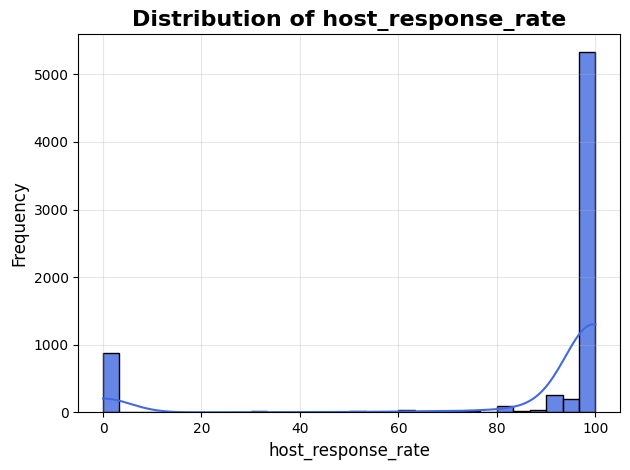

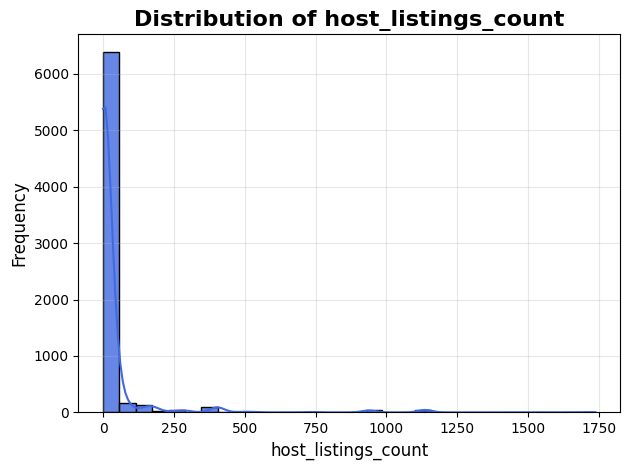

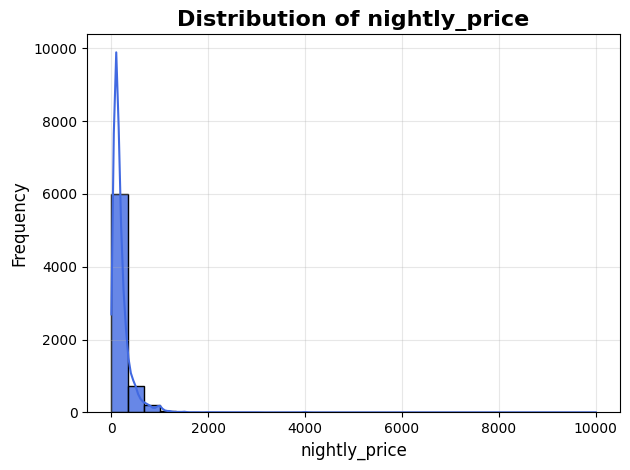

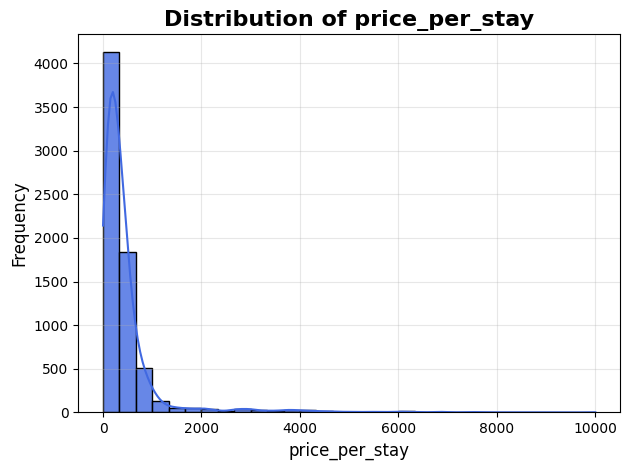

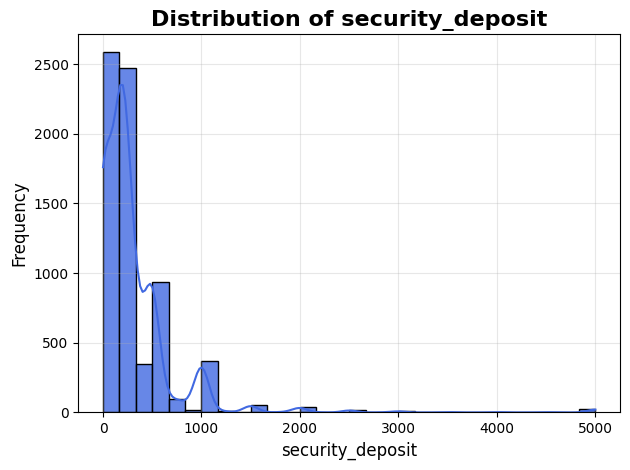

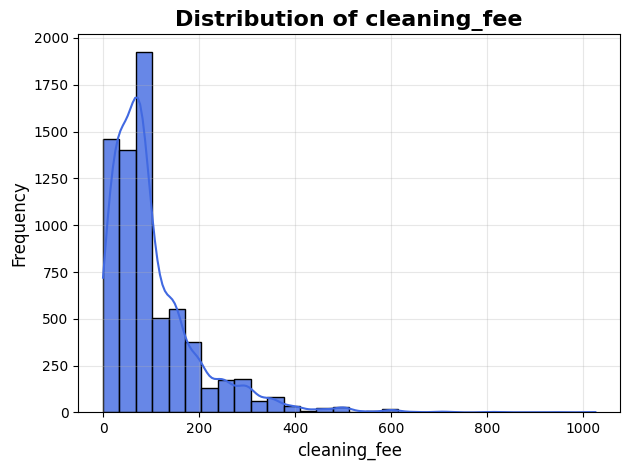

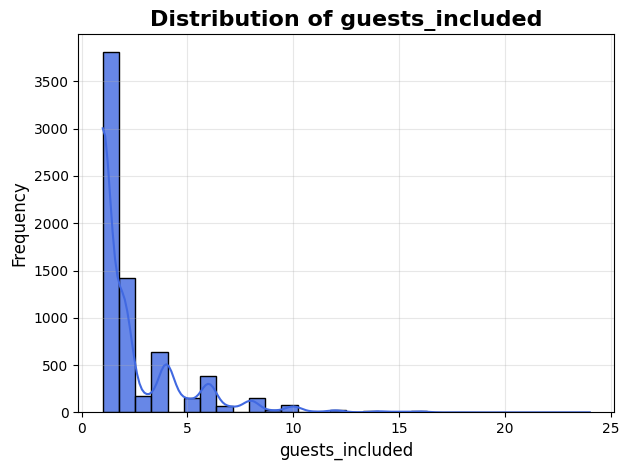

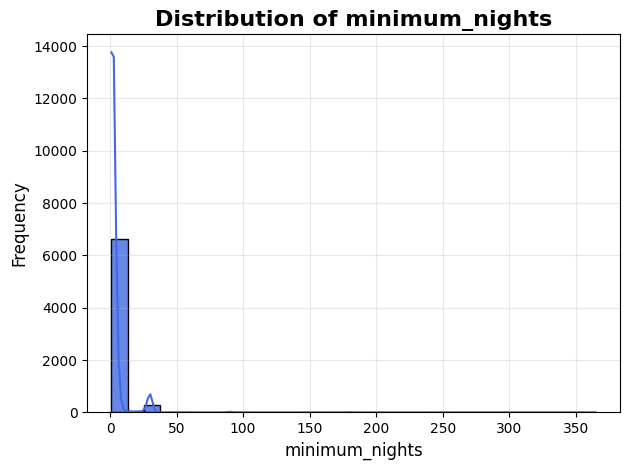

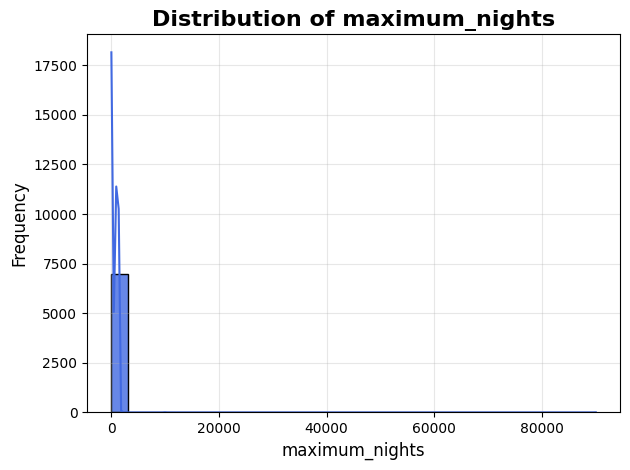

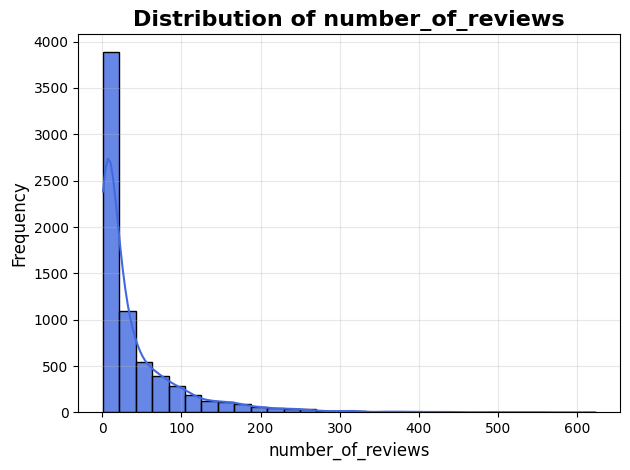

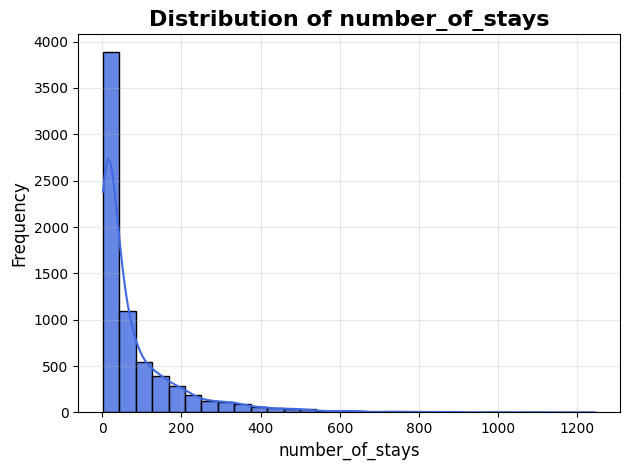

In [56]:
for col in second_vis_cols:

    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        color="royalblue",
        edgecolor="black",
        alpha=0.8
    )

    plt.title(f"Distribution of {col}", fontsize=16, fontweight="bold")
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

- all columns tend to have so much small values and nearly no big values 

- except the host respnse rate it tends

# Feature Engineering

 `important note` :  we will consider the values of each column in the test.csv file to make the data fit more



In [57]:
mt.data_info(df_test)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,host_since,str,"[3/22/2017, 8/5/2016, 8/23/2013, 2/14/2014, 1/...",1067,0,0.000000,0
1,host_response_time,str,"[within an hour, within a few hours, within a ...",4,201,11.518625,0
2,host_response_rate,float64,"[100.0, 0.0, 99.0, 90.0, 95.0, 98.0, 96.0, 97....",34,0,0.000000,0
3,host_is_superhost,str,"[f, t]",2,0,0.000000,0
4,host_listings_count,float64,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 403.0...",76,0,0.000000,0
5,host_identity_verified,str,"[t, f]",2,0,0.000000,0
6,state,str,[CA],1,0,0.000000,0
7,market,str,"[San Diego, Carlsbad, Other (Domestic)]",3,0,0.000000,0
8,country_code,str,[US],1,0,0.000000,0
9,country,str,[United States],1,0,0.000000,0


- columns like` state`, `country` and `country_code `will not be usfull if we make a feature from them

### word features

In [58]:
mt.data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,host_since,str,"[3/22/2017, 8/5/2016, 2/14/2014, 7/16/2015, 8/...",2165,1,0.014329,0
1,host_response_time,str,"[within an hour, within a few hours, within a ...",4,856,12.265368,0
2,host_response_rate,float64,"[100.0, 0.0, 99.0, 90.0, 95.0, 97.0, 96.0, 98....",47,0,0.000000,0
3,host_is_superhost,str,"[f, t]",2,0,0.000000,0
4,host_listings_count,float64,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 12.0, 8.0,...",86,0,0.000000,0
5,host_identity_verified,str,"[t, f]",2,0,0.000000,0
6,state,str,"[CA, Ca, California, Baja California, B.C., WA]",6,0,0.000000,0
7,market,str,"[San Diego, Carlsbad, Tijuana, Other (Domestic...",6,0,0.000000,0
8,country_code,str,"[US, MX, GB]",3,0,0.000000,0
9,country,str,"[United States, Mexico, United Kingdom]",3,0,0.000000,0


In [59]:
# regoin column

cols = ["latitude", "longitude"]

kmeans = KMeans(n_clusters=9, random_state=42)

df["regoin"] = kmeans.fit_predict(df[cols])
df_test["regoin"] = kmeans.predict(df_test[cols])

In [60]:
# avg number of nights 

df["avg_nights"] = (df["minimum_nights"] + df["maximum_nights"]) / 2
df_test["avg_nights"] = (df_test["minimum_nights"] + df_test["maximum_nights"]) / 2

In [61]:
# num of rooms

df["num_of_rooms"] = df["bedrooms"] + df["beds"]
df_test["num_of_rooms"] = df_test["bedrooms"] + df_test["beds"]

In [62]:
# total price per stay

df["total_price_per_stay"] = df["avg_nights"] * df["nightly_price"]
df_test["total_price_per_stay"] = df_test["avg_nights"] * df_test["nightly_price"]


In [63]:
# price per person

df["price_per_person"] = df["nightly_price"] / df["accommodates"]
df_test["price_per_person"] = df_test["nightly_price"] / df_test["accommodates"]

In [64]:
# price per room

df["price_per_room"] = df["nightly_price"] / (df["num_of_rooms"] + 1)
df_test["price_per_room"] = df_test["nightly_price"] / (df_test["num_of_rooms"] + 1)

In [65]:

df['review_ratio'] = df['number_of_reviews'] / (df['number_of_stays'] + 1)
df_test['review_ratio'] = df_test['number_of_reviews'] / (df_test['number_of_stays'] + 1)

In [66]:
# estimated total cost
   
df["estimated_total_cost"] = (
    df["nightly_price"] 
    + df["cleaning_fee"]
    + df["extra_people"] * df["guests_included"]
)
df_test["estimated_total_cost"] = (
    df_test["nightly_price"]
    + df_test["cleaning_fee"]
    + df_test["extra_people"] * df_test["guests_included"])

In [67]:
# luxury score

df["luxury_score"] = (
    (df["nightly_price"] > df["nightly_price"].median()).astype(int)
    +
    (df["accommodates"] >= 6).astype(int)
    +
    (df["num_of_rooms"] >= 3).astype(int)
)

df_test["luxury_score"] = (
    (df_test["nightly_price"] > df_test["nightly_price"].median()).astype(int)
    +
    (df_test["accommodates"] >= 6).astype(int)
    +
    (df_test["num_of_rooms"] >= 3).astype(int) )

In [68]:
# space efficiency score

df["space_efficiency"] = (
    df["accommodates"] / (df["num_of_rooms"] + 1)
)

df_test["space_efficiency"] = (
    df_test["accommodates"] / (df_test["num_of_rooms"] + 1)
)

In [69]:
# host since

df["host_since"] = pd.to_datetime(df["host_since"])

df["host_age_days"] = (
    pd.Timestamp.now() - df["host_since"]
).dt.days

df_test["host_since"] = pd.to_datetime(df_test["host_since"])

df_test["host_age_days"] = (
    pd.Timestamp.now() - df_test["host_since"]
).dt.days

In [70]:
# fixing the column and dropping the host_since column since we have the host_age_days column which is more useful

df = df.drop("host_since", axis=1)
df_test = df_test.drop("host_since", axis=1)

df["host_age_days"] = df["host_age_days"].fillna(df["host_age_days"].median())
df_test["host_age_days"] = df_test["host_age_days"].fillna(df_test["host_age_days"].median())

In [71]:
df["professional_host"] = (
    df["host_listings_count"] > 5
).astype(int)

df_test["professional_host"] = (
    df_test["host_listings_count"] > 5
).astype(int)

In [72]:
df['amenities_count'] = df['amenities'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
df_test['amenities_count'] = df_test['amenities'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)

In [73]:
df["total_extra_fees"] = df["security_deposit"] + df["cleaning_fee"]
df_test["total_extra_fees"] = df_test["security_deposit"] + df["cleaning_fee"]

In [74]:
df["fee_to_price_ratio"] = df["total_extra_fees"] / (df["nightly_price"] + 1)
df_test["fee_to_price_ratio"] = df_test["total_extra_fees"] / (df["nightly_price"] + 1)

In [75]:
df["occupancy_ratio"] = df["guests_included"] / df["accommodates"]
df_test["occupancy_ratio"] = df_test["guests_included"] / df_test["accommodates"]

In [76]:
df["luxury_index"] = (
      df["amenities_count"]*0.4
    + df["luxury_score"]*0.3
)

df_test["luxury_index"] = (
      df_test["amenities_count"]*0.4
    + df_test["luxury_score"]*0.3
)

In [77]:

df = df.drop("amenities", axis=1)
df_test = df_test.drop("amenities", axis=1)

In [78]:
mt.data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,host_response_time,str,"[within an hour, within a few hours, within a ...",4,856,12.265368,0
1,host_response_rate,float64,"[100.0, 0.0, 99.0, 90.0, 95.0, 97.0, 96.0, 98....",47,0,0.000000,0
2,host_is_superhost,str,"[f, t]",2,0,0.000000,0
3,host_listings_count,float64,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 12.0, 8.0,...",86,0,0.000000,0
4,host_identity_verified,str,"[t, f]",2,0,0.000000,0
5,state,str,"[CA, Ca, California, Baja California, B.C., WA]",6,0,0.000000,0
6,market,str,"[San Diego, Carlsbad, Tijuana, Other (Domestic...",6,0,0.000000,0
7,country_code,str,"[US, MX, GB]",3,0,0.000000,0
8,country,str,"[United States, Mexico, United Kingdom]",3,0,0.000000,0
9,latitude,float64,"[32.71043, 32.71077, 32.71083, 32.78276, 32.71...",5569,0,0.000000,0


# Splitting

In [79]:
x = df.drop("guest_satisfaction", axis=1)
y = df["guest_satisfaction"]

In [80]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Encoding

In [81]:
# encoding the target variable

target_map = {"Very High": 2, "High": 1, "Average": 0}

y_train = y_train.map(target_map)
y_test = y_test.map(target_map)

In [82]:
# try one hot encoder in bin cols

ohe_bin = OneHotEncoder(cols = bin_cols,
                       use_cat_names=True,
                       drop_invariant=True)

x_train = ohe_bin.fit_transform(x_train)
x_test = ohe_bin.transform(x_test)
df_test = ohe_bin.transform(df_test)


In [83]:
cat_cols = ["host_response_time", "state", "market",
            "country_code", "country", "room_type",
            "bed_type", "cancellation_policy"]


lbl_cols = ["cancellation_policy", "host_response_time", "room_type"]

- some columns will be ***one hot encoded*** and others will be ***label encoded***

- columns that needs the bias towards a spacific value like `cancellation_policy` column

- some other columns does not need that bias (will be one hot encoded) 

- ***important note:*** that the label columns each have there own dict so nothing goes wrong

In [84]:
# first column

df["host_response_time"].unique()

host_response_time_map = {'within an hour':4, 
            'within a few hours':3,
            'within a day':2,
            'a few days or more':1}

x_train["host_response_time"] = x_train["host_response_time"].map(host_response_time_map)
x_test["host_response_time"] = x_test["host_response_time"].map(host_response_time_map)
df_test["host_response_time"] = df_test["host_response_time"].map(host_response_time_map)

In [85]:
# second column

df["room_type"].unique()

room_type_map = {'Entire home/apt':3,
                 'Private room':2,
                 'Shared room':1}

x_train["room_type"] = x_train["room_type"].map(room_type_map)
x_test["room_type"] = x_test["room_type"].map(room_type_map)
df_test["room_type"] = df_test["room_type"].map(room_type_map)

In [86]:
# last column

df["cancellation_policy"].unique()

cancellation_policy_map = {
    'flexible': 1,
    'moderate': 2,
    'strict': 3,
    'strict_14_with_grace_period': 4,
    'super_strict_30': 5,
    'super_strict_60': 6
}

x_train["cancellation_policy"] = x_train["cancellation_policy"].map(cancellation_policy_map)
x_test["cancellation_policy"] = x_test["cancellation_policy"].map(cancellation_policy_map)
df_test["cancellation_policy"] = df_test["cancellation_policy"].map(cancellation_policy_map)

In [87]:
new_bin_cols = [x for x in cat_cols if x not in lbl_cols]

ohe_cat = OneHotEncoder(cols = new_bin_cols,
                       use_cat_names=True,
                       drop_invariant=True)

x_train = ohe_cat.fit_transform(x_train)
x_test = ohe_cat.transform(x_test)
df_test = ohe_cat.transform(df_test)


In [88]:
# filling nulls with a new class

x_train["host_response_time"] = x_train["host_response_time"].fillna(0)
x_test["host_response_time"] = x_test["host_response_time"].fillna(0)
df_test["host_response_time"] = df_test["host_response_time"].fillna(0)


# Correlation

In [89]:
mt.data_info(x_train)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,host_response_time,float64,"[4.0, 3.0, 0.0, 2.0, 1.0]",5,0,0.0,0
1,host_response_rate,float64,"[100.0, 0.0, 99.0, 90.0, 95.0, 97.0, 96.0, 98....",46,0,0.0,0
2,host_is_superhost_f,int64,"[1, 0]",2,0,0.0,0
3,host_is_superhost_t,int64,"[0, 1]",2,0,0.0,0
4,host_listings_count,float64,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 12.0,...",84,0,0.0,0
5,host_identity_verified_t,int64,"[0, 1]",2,0,0.0,0
6,host_identity_verified_f,int64,"[1, 0]",2,0,0.0,0
7,state_CA,int64,"[1, 0]",2,0,0.0,0
8,state_WA,int64,"[0, 1]",2,0,0.0,0
9,state_Baja California,int64,"[0, 1]",2,0,0.0,0


In [90]:
anova_scores, p_values = f_classif(
   x_train,
    y_train
)

anova_df = pd.DataFrame({
    "feature": x_train.columns,
    "F_score": anova_scores,
    "p_value": p_values
})


anova_df = anova_df.sort_values(
    "F_score",
    ascending=False
)

anova_df



,feature,F_score,p_value
2,host_is_superhost_f,389.318917,5.291815e-159
3,host_is_superhost_t,389.318917,5.291815e-159
444,review_ratio,263.534563,4.323179e-110
449,professional_host,130.572158,3.803405e-56
48,number_of_stays,106.477344,4.150002e-46
47,number_of_reviews,106.477344,4.150002e-46
450,amenities_count,58.499548,7.188780e-26
51,cancellation_policy,55.412907,1.480294e-24
454,luxury_index,51.823610,5.009192e-23
4,host_listings_count,41.571090,1.199740e-18


In [91]:
selected_features = anova_df[anova_df["F_score"] >= 5]["feature"]

x_train = x_train[selected_features]
x_test = x_test[selected_features]
df_test = df_test[selected_features]

# Scaling & Balancing (if needed)

In [92]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
df_test = scaler.transform(df_test)

## Balancing

In [93]:
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

# Model Training

In [94]:
# model = Sequential([Dense(512, activation = "relu"),
#                     Dropout(0.2),
                    
#                     Dense(256, activation = "relu"),
                
#                     Dense(64, activation = "relu"),
#                     Dropout(0.2),
                    
#                     Dense(32, activation = "relu"),
                    
                    
#                     Dense(18, activation = "relu"),
#                     Dropout(0.2),
                    
#                     Dense(8, activation = "relu"),
                    
                    
#                     Dense(3, activation = "softmax"),
#                     Dropout(0.2),])

In [95]:
# early_stopping = EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True)


# model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [96]:
# classes = np.unique(y_train)

# class_weights = compute_class_weight(
#     class_weight="balanced",
#     classes=classes,
#     y=y_train
# )

# class_weights = dict(zip(classes, class_weights))

In [97]:
# model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test), verbose=1, callbacks=[early_stopping],  class_weight=class_weights)

# Model Evaluation

In [ ]:
# # classification report

# predictions = model.predict(x_test)
# y_pred = np.argmax(predictions, axis=1)
# print(classification_report(y_test, y_pred))

AttributeError: 'SentenceTransformer' object has no attribute 'predict'

In [ ]:
# # F1Score 

# macro_f1 = f1_score(y_test, y_pred, average="macro")
# weighted_f1 = f1_score(y_test, y_pred, average="weighted")

# print("Macro F1:", macro_f1)
# print("Weighted F1:", weighted_f1)

## Random Forest


In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import classification_report, f1_score

# rf = RandomForestClassifier(
#     random_state=42,
#     n_jobs=-1,
#     class_weight="balanced"
# )

# param_grid = {
#     # Number of trees
#     "n_estimators": [200, 400, 600],

#     # Tree depth
#     "max_depth": [None, 10, 20, 30],

#     # Minimum samples needed to split a node
#     "min_samples_split": [2, 5, 10],

#     # Minimum samples required at a leaf
#     "min_samples_leaf": [1, 2, 4],

#     # Number of features considered at each split
#     "max_features": ["sqrt", "log2", 0.5],

#     # Bootstrap sampling
#     "bootstrap": [True, False]
# }


# grid = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid,
#     cv=5,
#     scoring="f1_macro",   # important for imbalanced multiclass
#     n_jobs=-1,
#     verbose=2
# )

# grid.fit(x_train, y_train)


# best_rf = grid.best_estimator_


In [ ]:
# best_rf = grid.best_estimator_

# train_pred = best_rf.predict(x_train)
# test_pred = best_rf.predict(x_test)

# print(f"train accuracy: {accuracy_score(y_train, train_pred)}")
# print(f"train accuracy: {accuracy_score(y_test, test_pred)}")
# print("#########################################################################")
# print(classification_report(y_test, test_pred))

In [ ]:
# model5
#               precision    recall  f1-score   support

#            0       0.53      0.63      0.57       418
#            1       0.42      0.21      0.28       319
#            2       0.62      0.70      0.66       659

#     accuracy                           0.57      1396
#    macro avg       0.52      0.51      0.51      1396
# weighted avg       0.55      0.57      0.55      1396

# model 8

#               precision    recall  f1-score   support

#            0       0.55      0.61      0.58       418
#            1       0.43      0.25      0.31       319
#            2       0.62      0.71      0.66       659

#     accuracy                           0.57      1396
#    macro avg       0.53      0.52      0.52      1396
# weighted avg       0.56      0.57      0.56      1396

# model 9
#               precision    recall  f1-score   support

#            0       0.57      0.58      0.58       418
#            1       0.36      0.47      0.41       319
#            2       0.68      0.56      0.62       659

#     accuracy                           0.55      1396
#    macro avg       0.54      0.54      0.53      1396
# weighted avg       0.57      0.55      0.56      1396


# model 10
#               precision    recall  f1-score   support

#            0       0.54      0.60      0.57       418
#            1       0.43      0.37      0.40       319
#            2       0.68      0.68      0.68       659

#     accuracy                           0.59      1396
#    macro avg       0.55      0.55      0.55      1396
# weighted avg       0.58      0.59      0.58      1396



# model 21


#               precision    recall  f1-score   support

#            0       0.58      0.57      0.58       418
#            1       0.46      0.20      0.28       319
#            2       0.63      0.81      0.71       659

#     accuracy                           0.60      1396
#    macro avg       0.56      0.53      0.52      1396
# weighted avg       0.58      0.60      0.57      1396


# model 22

#               precision    recall  f1-score   support

#            0       0.57      0.58      0.58       418
#            1       0.50      0.26      0.34       319
#            2       0.64      0.79      0.71       659

#     accuracy                           0.61      1396
#    macro avg       0.57      0.54      0.54      1396
# weighted avg       0.59      0.61      0.59      

# model 26

#               precision    recall  f1-score   support

#            0       0.67      0.46      0.55       418
#            1       0.40      0.21      0.28       319
#            2       0.61      0.87      0.71       659

#     accuracy                           0.60      1396
#    macro avg       0.56      0.51      0.51      1396
# weighted avg       0.58      0.60      0.57      1396


# model 31
#               precision    recall  f1-score   support

#            0       0.57      0.62      0.59       418
#            1       0.37      0.38      0.38       319
#            2       0.68      0.64      0.66       659

#     accuracy                           0.57      1396
#    macro avg       0.54      0.54      0.54      1396
# weighted avg       0.58      0.57      0.57      1396


# saving and applying the model

In [ ]:
# model.save("my_model31.keras")



In [ ]:
# model = load_model("my_model31.keras")

# reverse_mapping = {v: k for k, v in mapping.items()}

# pred = np.argmax(model.predict(df_test), axis=1)

# pred = [reverse_mapping[i] for i in pred]

In [ ]:
# submission = pd.DataFrame({
#     "id": id,
#     "target": pred
# })

# submission.to_csv("submission6.csv", index=False)

In [ ]:
# my model 1

# acro F1: 0.4978096005125283
# Weighted F1: 0.5459094113473522


# my model 2

# Macro F1: 0.5183675408530555
# Weighted F1: 0.543870097515503

# my model 3

# Macro F1: 0.5218367540853055
# Weighted F1: 0.5467890123456789

# model8
# Macro F1: 0.539324685493288
# Weighted F1: 0.5773116210114208

In [99]:


cat_model = CatBoostClassifier(
    loss_function="MultiClass",
    random_seed=42,
    verbose=0,
    eval_metric="TotalF1"
)


param_grid = {
    "depth": [5,6,7],
    "learning_rate": [0.02,0.05],
    "l2_leaf_reg": [5,10,20],
    "iterations": [800,1200,2000],
    "random_strength": [1,2]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


grid = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)


grid.fit(
    x_train,
    y_train
)


best_model = grid.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits


[CV] END depth=5, iterations=800, l2_leaf_reg=5, learning_rate=0.02, random_strength=1; total time= 2.6min
[CV] END depth=5, iterations=800, l2_leaf_reg=5, learning_rate=0.02, random_strength=1; total time= 2.6min
[CV] END depth=5, iterations=800, l2_leaf_reg=5, learning_rate=0.02, random_strength=1; total time= 2.6min
[CV] END depth=5, iterations=800, l2_leaf_reg=5, learning_rate=0.02, random_strength=1; total time= 2.7min
[CV] END depth=5, iterations=800, l2_leaf_reg=5, learning_rate=0.02, random_strength=2; total time= 2.6min
[CV] END depth=5, iterations=800, l2_leaf_reg=5, learning_rate=0.02, random_strength=1; total time= 2.7min
[CV] END depth=5, iterations=800, l2_leaf_reg=5, learning_rate=0.02, random_strength=2; total time= 2.7min
[CV] END depth=5, iterations=800, l2_leaf_reg=5, learning_rate=0.02, random_strength=2; total time= 2.7min


KeyboardInterrupt: 

In [ ]:
y_pred = best_model.predict(x_test)

print(accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred
))

0.6045845272206304
              precision    recall  f1-score   support

           0       0.61      0.56      0.58       418
           1       0.44      0.24      0.32       319
           2       0.64      0.81      0.71       659

    accuracy                           0.60      1396
   macro avg       0.56      0.54      0.54      1396
weighted avg       0.58      0.60      0.58      1396



In [ ]:
# model.save_model("catboost_model3.cbm")

# 0.5530085959885387
#               precision    recall  f1-score   support

#            0       0.55      0.63      0.58       424
#            1       0.41      0.45      0.43       324
#            2       0.65      0.56      0.60       648

#     accuracy                           0.55      1396
#    macro avg       0.54      0.54      0.54      1396
# weighted avg       0.56      0.55      0.56      1396

In [ ]:
# 0.5959885386819485
#               precision    recall  f1-score   support

#            0       0.60      0.53      0.56       424
#            1       0.52      0.27      0.36       324
#            2       0.61      0.80      0.69       648

#     accuracy                           0.60      1396
#    macro avg       0.58      0.53      0.54      1396
# weighted avg       0.59      0.60      0.58      1396

In [ ]:
mapping = {"Very High": 2, "High": 1, "Average": 0}
reverse_mapping = {v: k for k, v in mapping.items()}

# Predict classes
pred = best_model.predict(df_test).flatten()

# Convert numbers back to labels
pred = [reverse_mapping[i] for i in pred]

submission = pd.DataFrame({
    "id": id,
    "target": pred
})

submission.to_csv("submission18.csv", index=False)